# Phase 5: policy simulation

Compare manual, seasonal-naive and ML inventory policies on identical synthetic customer demand.
Forecasts use common prior POS history; lot expiry and lost sales are replayed independently.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
root = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'config/config.yaml').is_file())
sys.path.insert(0, str(root))
from src.utils.config import load_config, resolve_path
config = load_config()
print('Python:', sys.executable)
metrics = json.loads(resolve_path(config, 'simulation_metrics').read_text())
summary = pd.read_csv(resolve_path(config, 'simulation_summary'))
print('Test dates:', metrics['test_start'], 'through', metrics['test_end'])
print(summary.to_string(index=False))
print('Relative reductions vs manual:', json.dumps(metrics['relative_reduction_vs_manual'], indent=2))

Python: C:\Users\aamit\OneDrive\Desktop\ProjectX\coffee-inventory-ml\.venv\Scripts\python.exe
Test dates: 2025-07-20 through 2025-12-31
        policy  requested_units  served_units  lost_units  service_level  stockout_rate  item_day_stockout_rate   waste_cost  purchase_cost  holding_cost  lost_sale_penalty  initial_stock_value  closing_stock_value  pending_stock_value   total_cost
        manual            88436         87674         762       0.991384       0.008616                0.035152 44868.334286      2869065.0  15726.362923           111268.0         46171.554086         84630.758250              49990.0 3.042231e+06
seasonal_naive            88436         85810        2626       0.970306       0.029694                0.113939  5539.002286      2743660.0  12609.570405           403674.0         46171.554086         63012.970250              49450.0 3.206115e+06
            ml            88436         87053        1383       0.984362       0.015638                0.077576  1731

Waste is shown in native units per material; grams, milliliters and pieces are not added.
Negative relative reductions mean the comparison policy is worse. Total cost includes initial stock, procurement, holding and lost-sales penalty. Waste cost is already in procurement.

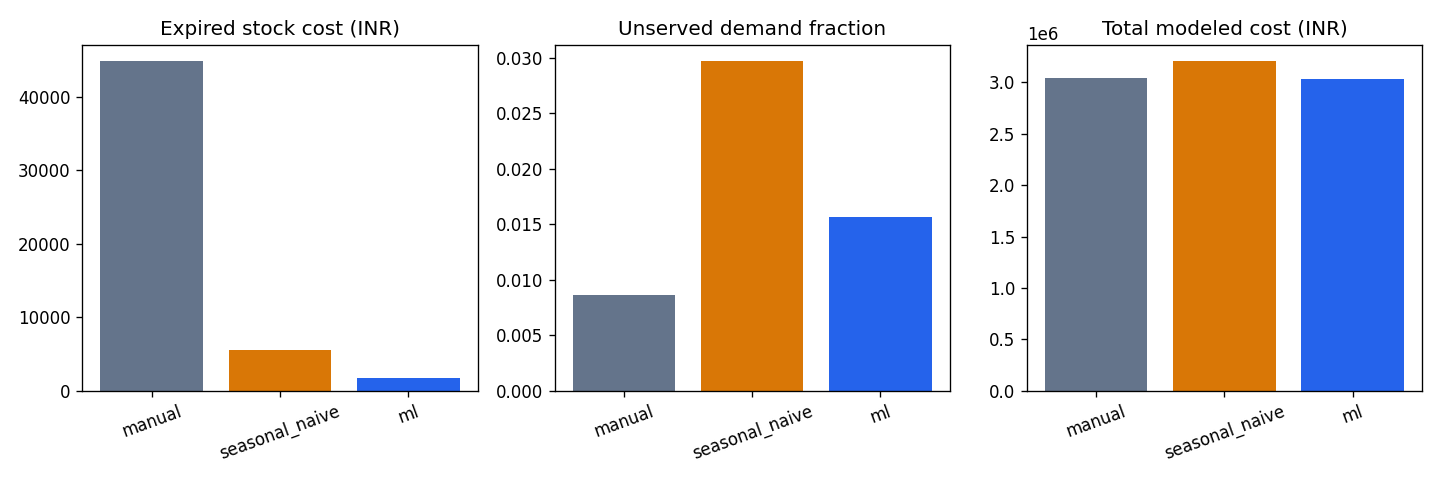

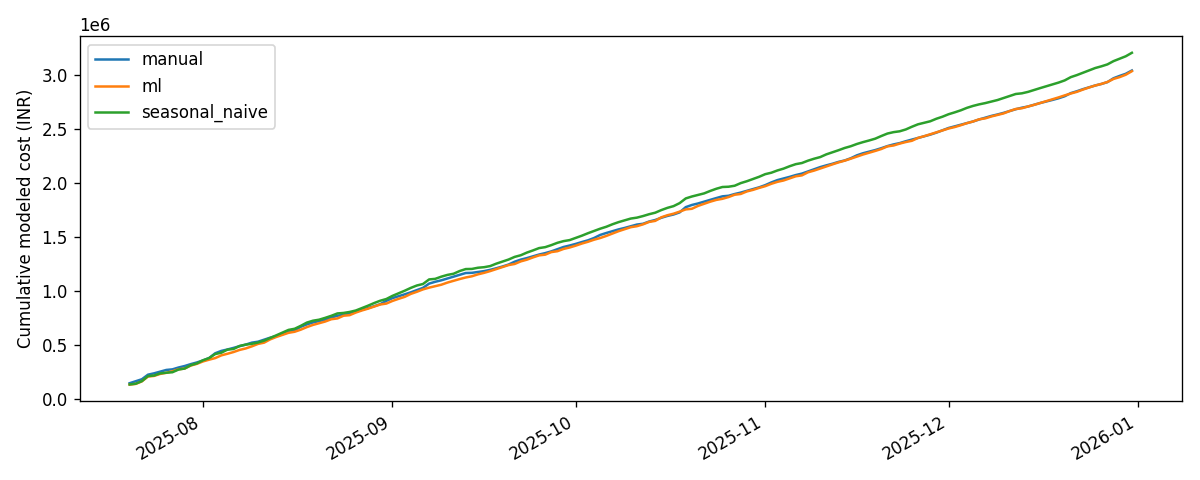

        policy        material unit   waste_units   waste_cost
        manual           bread  pcs    268.100000  2144.800000
        manual chocolate_syrup   ml      0.000000     0.000000
        manual    coffee_beans    g      0.000000     0.000000
        manual croissant_dough  pcs    192.497143  8662.371429
        manual        cup_cold  pcs      0.000000     0.000000
        manual         cup_hot  pcs      0.000000     0.000000
        manual             ice    g 213354.285714  2133.542857
        manual            milk   ml 532127.000000 31927.620000
        manual           sugar    g      0.000000     0.000000
        manual      tea_leaves    g      0.000000     0.000000
            ml           bread  pcs      4.140000    33.120000
            ml chocolate_syrup   ml      0.000000     0.000000
            ml    coffee_beans    g      0.000000     0.000000
            ml croissant_dough  pcs      0.000000     0.000000
            ml        cup_cold  pcs      0.000000     0

In [2]:
for name in config['simulation_figures'].values():
    display(Image(filename=str(resolve_path(config, 'figures') / name)))
waste = pd.read_csv(resolve_path(config, 'simulation_waste'))
print(waste.to_string(index=False))

In [3]:
daily = pd.read_csv(resolve_path(config, 'simulation'))
np.testing.assert_allclose(daily.opening + daily.received, daily.consumed + daily.waste + daily.closing, rtol=1e-10, atol=1e-6)
items = pd.read_csv(resolve_path(config, 'simulation_items'))
assert (items.demand == items.served + items.lost).all()
assert daily.closing.ge(0).all()
print('FIFO material mass balance and item demand reconciliation: PASS')
print('Daily material rows:', len(daily), '; item rows:', len(items))

FIFO material mass balance and item demand reconciliation: PASS
Daily material rows: 4950 ; item rows: 4950


## Limitations

Synthetic demand, weekly frozen forecasts, common factual POS history, fresh initial lots, deterministic item allocation and fixed lead times simplify the experiment. Forecast policies use shelf-life caps; the manual rule uses buffered historical means without that cap. Terminal stock and pipeline values are reported without salvage. No test-outcome tuning was performed. See docs/simulation_contract.md.